<a href="https://colab.research.google.com/github/farahnda/Learning/blob/main/SVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
c_names = ['post1', 'post2', 'post3', 'post4']
words = ['ice', 'snow', 'tahoe', 'ghost', 'puck']
post_words = pd.DataFrame([[4, 4, 6, 3],
                           [6, 1, 0, 5],
                           [3, 0, 0, 5],
                           [0, 6, 5, 1],
                           [0, 4, 5, 0]], index=words, columns=c_names)
post_words.index.names = ['word:']
post_words # PUNYA DATASET AWAL = MATRIKS

,post1,post2,post3,post4
word:,,,,
ice,4,4,6,3
snow,6,1,0,5
tahoe,3,0,0,5
ghost,0,6,5,1
puck,0,4,5,0


In [ ]:
import numpy as np

# SVD (mecah/faktorin 1 matriks gede -> 3 matriks kecil & lebih sederhana)
U, sigma, V = np.linalg.svd(post_words)
# hasilnya 3 bagian:
# U = simpan informasi hubungan antar words, baris 5 karna ada 5 kata
# SIGMA = TINGKAT KEPENTINGAN TIAP POLA
# V = HUBUNGAN POST DENGAN WORD
print(np.round(V, decimals=2)) # hasil dibulatkan 2 angka di belakang koma
# HASILNYA 4 BARIS DOANG KARNA JUMLAH TOPIK/WORD MAX = MIN(JUMLAH BARIS, JUMLAH KOLOM)

[[-0.4  -0.55 -0.61 -0.4 ]
 [-0.58  0.37  0.44 -0.58]
 [ 0.56 -0.46  0.41 -0.55]
 [-0.42 -0.59  0.52  0.45]]


In [ ]:
sigma # SIGMA = SINGULAR VALUES. BOBOTNYA. kek ranking, paling banyak informasi paling  no 1

array([13.55940373,  9.25515187,  2.06889804,  1.48472053])

In [ ]:
A_approx = np.matrix(U[:, :2])* np.diag(sigma[:2]) * np.matrix(V[:2, :])
# CUMA AMBIL 13.(...) & 9.(...) karna sdh bawa sebagian besar informasi
print(pd.DataFrame(A_approx, index = words, columns = c_names))
#PRINT APPROXIMATION MATRIX/MATRIKS PENDEKATANNYA

          post1     post2     post3     post4
ice    3.501303  4.788264  5.303188  3.479141
snow   5.534524  0.532173  0.412075  5.484183
tahoe  4.012803  0.069590 -0.059468  3.975616
ghost  0.507972  5.117862  5.779698  0.514380
puck  -0.008175  4.232570  4.794681  0.001110


In [ ]:
print(post_words - A_approx)
# HITUNG SELISIH, KALO KECIL -> PENDEKATAN BAGUS, KALO BESAR -> INFOMASI DIBUANG CUKUP BANYAK

          post1     post2     post3     post4
word:                                        
ice    0.498697 -0.788264  0.696812 -0.479141
snow   0.465476  0.467827 -0.412075 -0.484183
tahoe -1.012803 -0.069590  0.059468  1.024384
ghost -0.507972  0.882138 -0.779698  0.485620
puck   0.008175 -0.232570  0.205319 -0.001110


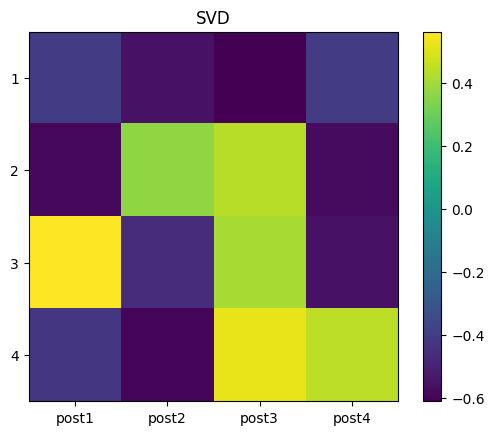

In [30]:
import matplotlib.pyplot as plt

plt.imshow(V, interpolation='none')
# TAMPILIN ISI MATRIKS V SEBAGAI GAMNAR HEATMAP
plt.xticks(range(len(c_names))) # SUMBU X= POST1, DST
plt.yticks(range(len(words))) # SUMBU Y = WORDS
plt.ylim([len(words) -1.5, -.5]) # TRIK BIAR HEATMAP GA KEPOTONG
ax = plt.gca()
# AMBIL OBJEK GRAFIK YANG SEDANG AKTIF SUPAYA LABEL SUMBU DAPAT DIUBAH
ax.set_xticklabels(c_names) # UBAH 0 1 2 3 JADI POST1 DST
ax.set_yticklabels(range(1, len(words) +1)) # BUKAN NAMPILIN WORDS, TAPI 1 2 3 4
plt.title('SVD')
plt.colorbar() # TAMBAHIN LEGENDA WARNA

In [31]:
U

array([[-0.64045296,  0.00144721,  0.57604649,  0.27345413, -0.42803177],
       [-0.3674885 , -0.6512583 ,  0.07115289, -0.60919765,  0.25422493],
       [-0.23746333, -0.501568  , -0.52239861,  0.64440996,  0.06225917],
       [-0.49828194,  0.4110229 , -0.61746402, -0.3354334 , -0.29832517],
       [-0.38742546,  0.39414495,  0.09458112,  0.16223841,  0.81196329]])

In [ ]:
pd.DataFrame(U[:, 1], index=words)
# AMBIL MATRIKS U, AMBIL KOLOM KE 2, UBAH JADI DF, PAKE DAFTAR WORDS AS NAMA BARIS

,0
ice,0.001447
snow,-0.651258
tahoe,-0.501568
ghost,0.411023
puck,0.394145
